# Sentiment Analysis: BERT VS GPT
This study applies two approaches to sentiment classification: a fine-tuned BERT model and a prompt-based GPT model. Both models are evaluated using the same dataset and performance metrics to ensure a fair comparison.

In [1]:
#Import required libraries
import pandas as pd
import numpy as np
import re
import torch
import transformers


In [2]:
# Load dataset
df=pd.read_csv("glassdoor_reviews.csv")

# 1. Data Preparation

In [3]:
df.head()

,firm,date_review,job_title,current,location,overall_rating,work_life_balance,culture_values,diversity_inclusion,career_opp,comp_benefits,senior_mgmt,recommend,ceo_approv,outlook,headline,pros,cons
0,AFH-Wealth-Management,2015-04-05,,Current Employee,NaN,2,4.0,3.0,NaN,2.0,3.0,3.0,x,o,r,"Young colleagues, poor micro management",Very friendly and welcoming to new staff. Easy...,"Poor salaries, poor training and communication."
1,AFH-Wealth-Management,2015-12-11,Office Administrator,"Current Employee, more than 1 year","Bromsgrove, England, England",2,3.0,1.0,NaN,2.0,1.0,4.0,x,o,r,"Excellent staff, poor salary","Friendly, helpful and hard-working colleagues",Poor salary which doesn't improve much with pr...
2,AFH-Wealth-Management,2016-01-28,Office Administrator,"Current Employee, less than 1 year","Bromsgrove, England, England",1,1.0,1.0,NaN,1.0,1.0,1.0,x,o,x,"Low salary, bad micromanagement",Easy to get the job even without experience in...,"Very low salary, poor working conditions, very..."
3,AFH-Wealth-Management,2016-04-16,,Current Employee,NaN,5,2.0,3.0,NaN,2.0,2.0,3.0,x,o,r,Over promised under delivered,Nice staff to work with,No career progression and salary is poor
4,AFH-Wealth-Management,2016-04-23,Office Administrator,"Current Employee, more than 1 year","Bromsgrove, England, England",1,2.0,1.0,NaN,2.0,1.0,1.0,x,o,x,client reporting admin,"Easy to get the job, Nice colleagues.","Abysmal pay, around minimum wage. No actual tr..."


In [4]:
df.isnull().sum()

firm                        0
date_review                 0
job_title                   0
current                     0
location               297343
overall_rating              0
work_life_balance      149894
culture_values         191373
diversity_inclusion    702500
career_opp             147501
comp_benefits          150082
senior_mgmt            155876
recommend                   0
ceo_approv                  0
outlook                     0
headline                 2590
pros                        2
cons                       13
dtype: int64

In [5]:
# Select only the required columns for analysis
cols=["firm", "overall_rating","headline","pros","cons","location"]

In [6]:
df= df[cols].copy()

In [7]:
df.shape

(838566, 6)

In [8]:
df.columns.tolist()

['firm', 'overall_rating', 'headline', 'pros', 'cons', 'location']

# 2. Data Preprocessing

## 2.1 Handling Missing Values

In [9]:
text_cols=['headline', 'pros', 'cons']
for col in text_cols:
    df[col]=df[col].fillna("")

In [10]:
df[text_cols].isnull().sum()

headline    0
pros        0
cons        0
dtype: int64

In [11]:
# Combine headline, pros, and cons into one review field
df["review"]=(
    df['headline']+ " "+ df['pros']+ " " +df['cons']
)

In [12]:
df.head()

,firm,overall_rating,headline,pros,cons,location,review
0,AFH-Wealth-Management,2,"Young colleagues, poor micro management",Very friendly and welcoming to new staff. Easy...,"Poor salaries, poor training and communication.",NaN,"Young colleagues, poor micro management Very f..."
1,AFH-Wealth-Management,2,"Excellent staff, poor salary","Friendly, helpful and hard-working colleagues",Poor salary which doesn't improve much with pr...,"Bromsgrove, England, England","Excellent staff, poor salary Friendly, helpful..."
2,AFH-Wealth-Management,1,"Low salary, bad micromanagement",Easy to get the job even without experience in...,"Very low salary, poor working conditions, very...","Bromsgrove, England, England","Low salary, bad micromanagement Easy to get th..."
3,AFH-Wealth-Management,5,Over promised under delivered,Nice staff to work with,No career progression and salary is poor,NaN,Over promised under delivered Nice staff to wo...
4,AFH-Wealth-Management,1,client reporting admin,"Easy to get the job, Nice colleagues.","Abysmal pay, around minimum wage. No actual tr...","Bromsgrove, England, England","client reporting admin Easy to get the job, Ni..."


In [13]:
def clean_text(text):
    text=re.sub(r"¥s+", " ",text)
    return text.strip()

In [14]:
df["review"] = df["review"].apply(clean_text)

In [15]:
df[["review"]].head()

,review
0,"Young colleagues, poor micro management Very f..."
1,"Excellent staff, poor salary Friendly, helpful..."
2,"Low salary, bad micromanagement Easy to get th..."
3,Over promised under delivered Nice staff to wo...
4,"client reporting admin Easy to get the job, Ni..."


## 2.2 Sentiment Label Mapping

In [16]:
def map_sentiment(rating):
    if rating in [1,2]:
        return 0
    elif rating == 3:
        return 1
    elif rating in [4,5]:
        return 2
    else:
        return np.nan
        

In [17]:
df["label"]= df["overall_rating"].apply(map_sentiment)

In [18]:
df.head(10)

,firm,overall_rating,headline,pros,cons,location,review,label
0,AFH-Wealth-Management,2,"Young colleagues, poor micro management",Very friendly and welcoming to new staff. Easy...,"Poor salaries, poor training and communication.",NaN,"Young colleagues, poor micro management Very f...",0
1,AFH-Wealth-Management,2,"Excellent staff, poor salary","Friendly, helpful and hard-working colleagues",Poor salary which doesn't improve much with pr...,"Bromsgrove, England, England","Excellent staff, poor salary Friendly, helpful...",0
2,AFH-Wealth-Management,1,"Low salary, bad micromanagement",Easy to get the job even without experience in...,"Very low salary, poor working conditions, very...","Bromsgrove, England, England","Low salary, bad micromanagement Easy to get th...",0
3,AFH-Wealth-Management,5,Over promised under delivered,Nice staff to work with,No career progression and salary is poor,NaN,Over promised under delivered Nice staff to wo...,2
4,AFH-Wealth-Management,1,client reporting admin,"Easy to get the job, Nice colleagues.","Abysmal pay, around minimum wage. No actual tr...","Bromsgrove, England, England","client reporting admin Easy to get the job, Ni...",0
5,AFH-Wealth-Management,3,Office administrator,Some good people to work with.\n\nFlexible wor...,Morale.\n\nLack of managerial structure.\n\nDo...,NaN,Office administrator Some good people to work ...,1
6,AFH-Wealth-Management,1,It horrible management,Good investment management strategy. Overall t...,The management and seniors are ruthless. No tr...,"Bromsgrove, England, England",It horrible management Good investment managem...,0
7,AFH-Wealth-Management,5,Good place to work,The people are great and the culture is very f...,Wouldn't necessarily say there are any cons to...,"Century City, CA",Good place to work The people are great and th...,2
8,AFH-Wealth-Management,4,I liked working for AFH,"Nice Staff, good HR Team.\r\nFeels vibrant and...",Can't really think of any obvious cons,NaN,"I liked working for AFH Nice Staff, good HR Te...",2
9,AFH-Wealth-Management,1,Honest Review,Made some life time friends.,Was let go from the company just before Christ...,"Santa Ana, CA",Honest Review Made some life time friends. Was...,0


In [19]:
df["label"].value_counts()

label
2    510532
1    194267
0    133767
Name: count, dtype: int64

In [20]:
df["review"].str.len().describe()

count    838566.000000
mean        239.699535
std         297.161892
min          32.000000
25%         101.000000
50%         146.000000
75%         270.000000
max       18623.000000
Name: review, dtype: float64

In [21]:
df["location"].value_counts()

location
London, England, England    58665
New York, NY                31172
Bangalore                   28102
Hyderābād                   11458
Mumbai                       9543
                            ...  
Herning                         1
Hawai                           1
Vejle                           1
Lainate                         1
Wijnegem, Antwerp               1
Name: count, Length: 14486, dtype: int64

In [22]:
# Restrict the dataset to london for consistency in workplace context
df=df[df["location"]=="London, England, England"].copy()

In [23]:
df.head()

,firm,overall_rating,headline,pros,cons,location,review,label
97,AJ-Bell,4,Good opportunities to progress - an improving ...,Plenty of opportunities for the right people t...,Very different cultures between Manchester & L...,"London, England, England",Good opportunities to progress - an improving ...,2
131,AJ-Bell,5,Good company to work for,"Sociable work place, good progression.",Salary is on the lower end of the spectrum.,"London, England, England","Good company to work for Sociable work place, ...",2
133,AJ-Bell,5,Good,Nice people to work with,Nothing much is negative to say,"London, England, England",Good Nice people to work with Nothing much is ...,2
145,AJ-Bell,2,Run!!,Great momentum after the company floated,"Poor salary, no freedom to express yourself","London, England, England",Run!! Great momentum after the company floated...,0
200,ALDI,3,My experience working for ALDI,"Great staff, decent pay, as many hours as you ...",The rota can be an nightmare. Your shifts can ...,"London, England, England","My experience working for ALDI Great staff, de...",1


In [24]:
df["label"].value_counts(normalize=True)

label
2    0.602199
1    0.223967
0    0.173834
Name: proportion, dtype: float64

## 2.3 split data to training and test sets using stratified sampling

In [26]:
from sklearn.model_selection import train_test_split
train_df, test_df=train_test_split(df, test_size=0.2,random_state=42, stratify=df["label"])

In [27]:
train_df.shape

(46932, 8)

In [28]:
test_df.shape

(11733, 8)

In [29]:
train_df["label"].value_counts(normalize=True)

label
2    0.602190
1    0.223962
0    0.173847
Name: proportion, dtype: float64

In [30]:
test_df["label"].value_counts(normalize=True)

label
2    0.602233
1    0.223984
0    0.173783
Name: proportion, dtype: float64

In [31]:
test_df["label"].value_counts()

label
2    7066
1    2628
0    2039
Name: count, dtype: int64

In [32]:
train_texts= train_df["review"].tolist()

In [33]:
test_texts= test_df["review"].tolist()

In [34]:
train_labels= train_df["label"].tolist()

In [35]:
test_labels= test_df["label"].tolist()

## 2.4 Tokenization 

In [36]:
# Load the BERT tokenizer for text encoding
from transformers import BertTokenizer
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

In [37]:
train_encodings = tokenizer(
    train_texts,
    truncation=True,
    padding=True,
    max_length=128
)
test_encodings = tokenizer(
    test_texts,
    truncation=True,
    padding=True,
    max_length=128
)

In [38]:
# Simple Dataset class — wraps the tokenized data
class GlassdoorDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels    = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        # Return one sample: the tokenized inputs + its label
        return {
            'input_ids':      self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'labels':         torch.tensor(self.labels[idx], dtype=torch.long)
        }

In [39]:
train_dataset = GlassdoorDataset(train_encodings, train_labels)

In [40]:
test_dataset = GlassdoorDataset(test_encodings, test_labels)

In [41]:
len(train_dataset)

46932

In [42]:
len(test_dataset)

11733

# 3. BERT Model Implementation

## 3.1 Model setup

In [43]:
# Load a pre-trained BERT model for 3-class sentiment classification
from transformers import BertForSequenceClassification
model= BertForSequenceClassification.from_pretrained (
    "bert-base-uncased",
    num_labels=3
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## 3.2 Training Configuration

In [44]:
from transformers import TrainingArguments

training_arg=TrainingArguments(
    output_dir="./results",
    num_train_epochs=1,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
      eval_strategy="no"
)

In [45]:
#Initialize Trainer for fine-tuning BERT
from transformers import Trainer
trainer = Trainer(
    model=model,
    args=training_arg,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)

## 3.3 Model Training

In [46]:
trainer.train()

/opt/anaconda3/envs/hftrain/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss
500,0.746329
1000,0.690528
1500,0.674613
2000,0.644474
2500,0.638873
3000,0.629692
3500,0.622606
4000,0.621332
4500,0.603254
5000,0.589607


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=5867, training_loss=0.6358203670123945, metrics={'train_runtime': 15391.6016, 'train_samples_per_second': 3.049, 'train_steps_per_second': 0.381, 'total_flos': 3087109730202624.0, 'train_loss': 0.6358203670123945, 'epoch': 1.0})

In [47]:
# Generate predictions on the test dataset
predictions= trainer.predict(test_dataset)

/opt/anaconda3/envs/hftrain/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


In [48]:

y_pred = np.argmax(predictions.predictions, axis=1)
y_true = test_labels


# 4.BERT Model Evaluation

## 4.1 Metrics

In [49]:
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_true,y_pred))
print(confusion_matrix(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.77      0.67      0.71      2039
           1       0.52      0.43      0.47      2628
           2       0.83      0.91      0.87      7066

    accuracy                           0.76     11733
   macro avg       0.70      0.67      0.68     11733
weighted avg       0.75      0.76      0.75     11733

[[1361  465  213]
 [ 363 1142 1123]
 [  55  600 6411]]


In [50]:
import seaborn as sns 
import matplotlib.pyplot as plt
cm =confusion_matrix(y_true, y_pred)

## 4.2 Confusion Matrix 

Text(0.5, 1.0, 'Confusion Matrix - BERT Model')

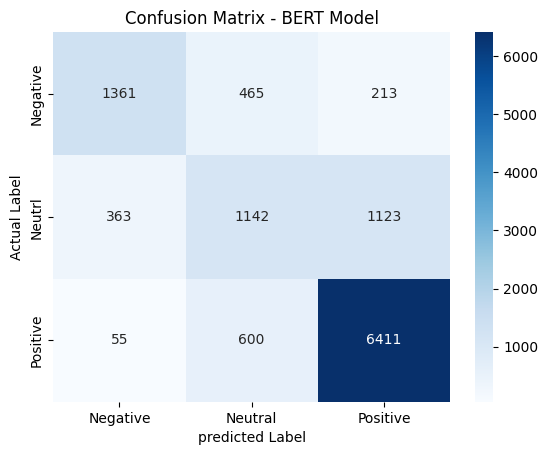

In [51]:
sns.heatmap(cm, annot =True, fmt="d", cmap="Blues",
           xticklabels=["Negative","Neutral","Positive"],
           yticklabels=["Negative","Neutrl","Positive"])
plt.xlabel("predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - BERT Model")

# 5. GPT Model Implementation

## 5.1 Prompt design

In [52]:
import requests

def get_sentiment(text):
    prompt = f"""
    You are a sentiment classification specialist.
    Classify the following employee review into exactly one of these labels:
    Negative
    Neutral
    Positive
    
    Rules:
    - Return only one word: Negative, Neutral, or Positive
    - Do not explain 
    - Do not add extra text

    Review:
    Text: "{text}"
    """

    response = requests.post(
        "http://localhost:11434/api/generate",
        json={
            "model": "llama3.1",
            "prompt": prompt,
            "stream": False
        }
    )

    return response.json()["response"].strip()

# Test example
text = "Great team, supportive manager!"
result = get_sentiment(text)

print("Text:", text)
print("Sentiment:", result)


Text: Great team, supportive manager!
Sentiment: Positive


## 5.2 GPT Inference on Evaluation Subset

In [53]:
# select a stratified subset of 10,000 test samples due to computational constraints
from sklearn.model_selection import train_test_split

gpt_test_df, _ = train_test_split(
    test_df,
    train_size=10000,
    stratify=test_df["label"],
    random_state=42
)

print(gpt_test_df.shape)
print(gpt_test_df["label"].value_counts())

(10000, 8)
label
2    6022
1    2240
0    1738
Name: count, dtype: int64


## 5.3 Label Mapping 

In [54]:
gpt_predictions_text = []

for i, text in enumerate(gpt_test_df["review"]):
    pred = get_sentiment(text)
    gpt_predictions_text.append(pred)

    if i % 500 == 0:
        print(f"Processed {i} reviews")
        

Processed 0 reviews
Processed 500 reviews
Processed 1000 reviews
Processed 1500 reviews
Processed 2000 reviews
Processed 2500 reviews
Processed 3000 reviews
Processed 3500 reviews
Processed 4000 reviews
Processed 4500 reviews
Processed 5000 reviews
Processed 5500 reviews
Processed 6000 reviews
Processed 6500 reviews
Processed 7000 reviews
Processed 7500 reviews
Processed 8000 reviews
Processed 8500 reviews
Processed 9000 reviews
Processed 9500 reviews


In [55]:
# Map GPT text outputs to numeric sentiment labels
def label(pred):
    pred = pred.strip().lower()
    if "negative" in pred:
        return 0
    elif "neutral" in pred:
        return 1
    elif "positive" in pred:
        return 2
    else:
        return -1
gpt_y_true = gpt_test_df["label"].tolist()
gpt_y_pred =[label(pred) for pred in gpt_predictions_text]
print("invalid prediction:", sum(1 for x in gpt_y_pred if x==-1))

invalid prediction: 0


# 6. GPT Model Evaluation 

## 6.1 Metrics

In [56]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
print(classification_report(gpt_y_true,gpt_y_pred))
print(confusion_matrix(gpt_y_true, gpt_y_pred))

              precision    recall  f1-score   support

           0       0.37      0.91      0.52      1738
           1       0.24      0.29      0.26      2240
           2       0.93      0.45      0.61      6022

    accuracy                           0.50     10000
   macro avg       0.51      0.55      0.46     10000
weighted avg       0.68      0.50      0.52     10000

[[1577  123   38]
 [1413  656  171]
 [1303 1986 2733]]


## 6.2 Confusion Matrix

Text(0.5, 1.0, 'Confusion Matrix - GPT Model')

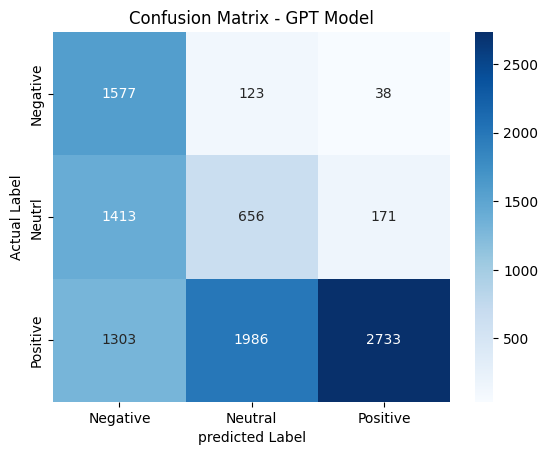

In [57]:

import seaborn as sns 
import matplotlib.pyplot as plt
gpt_cm =confusion_matrix(gpt_y_true, gpt_y_pred)

sns.heatmap(gpt_cm, annot =True, fmt="d", cmap="Blues",
           xticklabels=["Negative","Neutral","Positive"],
           yticklabels=["Negative","Neutral","Positive"])
plt.xlabel("predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - GPT Model")